# 환경설정

In [ ]:
!pip install koreanize_matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 35.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#데이터 합치기

## 기존 데이터 합치기

In [ ]:
import pandas as pd
from functools import reduce
import os

# 1. 파일이 위치한 기본 폴더 경로 설정
base_path = "/content/drive/MyDrive/코드잇_데이터분석_14기/00_ETC/프로젝트01/clean"

# 2. 7개의 CSV 파일명 리스트
file_names = [
    '2023년_기온_데이터.csv',
    '미세먼지(수정).csv',
    '서울시_월별_구별_점포수_데이터.csv',
    '온라인쇼핑몰.csv',
    '택배데이터_23년.csv',
    '한강이용객_23년.csv',
    'gu__month_activity_index.csv'
]

# 3. 데이터를 불러오면서 불필요한 'Unnamed' 컬럼을 제거
dfs = []
for f in file_names:
    df = pd.read_csv(os.path.join(base_path, f))
    # 'Unnamed'로 시작하는 컬럼이 있다면 모두 제외하고 가져오기
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    dfs.append(df)

# 4. '월'과 '자치구'를 기준으로 7개의 데이터를 하나로 병합
final_merged_df = reduce(lambda left, right: pd.merge(left, right, on=['월', '자치구'], how='inner'), dfs)

final_merged_df

,자치구,월,평균기온(℃),평균최저기온(℃),평균최고기온(℃),미세먼지(㎍/㎥),초미세먼지(㎍/㎥),점포_수,유사_업종_점포_수,개업_율,...,대분류_착지물동량 생활/건강,대분류_착지물동량 스포츠/레저,대분류_착지물동량 식품,대분류_착지물동량 출산/육아,대분류_착지물동량 패션의류,대분류_착지물동량 패션잡화,대분류_착지물동량 화장품/미용,총이용량,총이용객,활동지수
0,강남구,1,-1.522581,-5.693548,3.196774,46.548387,25.032258,59392.0,64096.0,291.2,...,306190,36007,627011,35804,261093,118388,187383,2108389,9525350.0,1.481311
1,강남구,2,2.300000,-1.864286,7.289286,45.928571,27.857143,59392.0,64096.0,291.2,...,264988,33081,428501,33097,252691,115006,169052,1796820,9321990.0,1.546100
2,강남구,3,9.780645,4.180645,16.187097,65.419355,26.612903,59392.0,64096.0,291.2,...,302711,41673,481077,37088,334607,137722,196116,2088840,11947583.0,1.531621
3,강남구,4,13.800000,8.806667,18.953333,59.966667,19.300000,59965.0,64679.0,302.9,...,276549,40119,424034,36641,317236,133714,168616,1883898,17884868.0,1.493406
4,강남구,5,19.522581,14.606452,25.041935,37.806452,17.580645,59965.0,64679.0,302.9,...,300592,45735,443396,38318,357227,145392,185915,2033278,18029351.0,1.489154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,중랑구,8,27.187097,24.309677,30.764516,22.419355,14.483871,17001.0,18604.0,298.0,...,122591,18514,199399,19123,133379,61084,77289,805634,12945997.0,0.867274
296,중랑구,9,23.663333,20.233333,27.616667,21.551724,12.275862,17001.0,18604.0,298.0,...,109610,16256,215463,16651,118538,50623,69332,751480,14438789.0,0.876349
297,중랑구,10,15.793548,11.480645,20.993548,26.870968,14.516129,17085.0,18703.0,247.6,...,115555,19353,184085,18217,166918,60681,74101,812851,17311828.0,0.870865
298,중랑구,11,6.796667,2.850000,11.516667,26.733333,17.366667,17085.0,18703.0,247.6,...,134606,22600,218311,20516,183207,75954,85108,931881,8798349.0,0.872468


## 검색량 데이터 합치기

In [ ]:
data_path = "/content/drive/MyDrive/코드잇_데이터분석_14기/00_ETC/프로젝트01/clean/검색량.csv"
din_df = pd.read_csv(data_path)
din_df

,월,벚꽃_합계,맛집_합계
0,1,23,429
1,2,34,344
2,3,153,305
3,4,65,399
4,5,11,298
5,6,10,303
6,7,10,388
7,8,11,298
8,9,9,270
9,10,11,339


In [ ]:
import pandas as pd

# 1. 서울시 25개 자치구 리스트 생성
seoul_districts = [
    '강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구',
    '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구',
    '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구'
]

# 2. 자치구 리스트를 데이터프레임으로 변환
districts_df = pd.DataFrame({'자치구': seoul_districts})

# 3. 기존 데이터(din_df)와 자치구 데이터(districts_df)를 교차 조인 (Cross Join)
# 12개월 * 25개 자치구 = 총 300개의 행 생성
result_df = din_df.merge(districts_df, how='cross')

# 4. 컬럼 순서 재배치
result_df = result_df[['월', '자치구', '벚꽃_합계', '맛집_합계']]

result_df

,월,자치구,벚꽃_합계,맛집_합계
0,1,강남구,23,429
1,1,강동구,23,429
2,1,강북구,23,429
3,1,강서구,23,429
4,1,관악구,23,429
...,...,...,...,...
295,12,용산구,21,459
296,12,은평구,21,459
297,12,종로구,21,459
298,12,중구,21,459


In [ ]:
# 1부터 12까지 돌면서, 숫자를 2자리(02) 정수(d) 형태로 포맷팅
cols_23 = [f'{i:02d}' for i in range(1, 13)]


In [ ]:
# 1. 데이터를 문자열(str)로 변환한 뒤, 2자리가 되도록 앞을 '0'으로 채움
result_df['월'] = result_df['월'].astype(str).str.zfill(2)

result_df

,월,자치구,벚꽃_합계,맛집_합계
0,01,강남구,23,429
1,01,강동구,23,429
2,01,강북구,23,429
3,01,강서구,23,429
4,01,관악구,23,429
...,...,...,...,...
295,12,용산구,21,459
296,12,은평구,21,459
297,12,종로구,21,459
298,12,중구,21,459


In [ ]:
# 1. 두 데이터프레임의 '월' 컬럼을 모두 문자열 2자리(01, 02...)로 통일
result_df['월'] = result_df['월'].astype(str).str.zfill(2)
final_merged_df['월'] = final_merged_df['월'].astype(str).str.zfill(2)

total_df = pd.merge(result_df, final_merged_df, on=['자치구', '월'])

total_df

,월,자치구,벚꽃_합계,맛집_합계,평균기온(℃),평균최저기온(℃),평균최고기온(℃),미세먼지(㎍/㎥),초미세먼지(㎍/㎥),점포_수,...,대분류_착지물동량 생활/건강,대분류_착지물동량 스포츠/레저,대분류_착지물동량 식품,대분류_착지물동량 출산/육아,대분류_착지물동량 패션의류,대분류_착지물동량 패션잡화,대분류_착지물동량 화장품/미용,총이용량,총이용객,활동지수
0,01,강남구,23,429,-1.522581,-5.693548,3.196774,46.548387,25.032258,59392.0,...,306190,36007,627011,35804,261093,118388,187383,2108389,9525350.0,1.481311
1,01,강동구,23,429,-1.522581,-5.693548,3.196774,49.483871,28.161290,22318.0,...,164268,19447,334261,30607,148631,73229,102751,1124043,9525350.0,1.081657
2,01,강북구,23,429,-1.522581,-5.693548,3.196774,48.935484,24.580645,13365.0,...,91329,10590,192935,11919,91448,37698,56350,622408,9525350.0,0.959580
3,01,강서구,23,429,-1.522581,-5.693548,3.196774,57.193548,25.161290,29257.0,...,233182,27409,452563,36273,228895,93634,148532,1580044,9525350.0,0.936711
4,01,관악구,23,429,-1.522581,-5.693548,3.196774,49.645161,23.548387,20230.0,...,176310,20835,359645,21379,179532,79151,121633,1231855,9525350.0,0.903117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,12,용산구,21,459,1.116129,-2.503226,5.225806,34.516129,18.903226,19216.0,...,114347,15286,180812,17346,98863,80918,66971,753359,7446751.0,1.251835
296,12,은평구,21,459,1.116129,-2.503226,5.225806,34.419355,19.645161,19386.0,...,167827,24306,274096,31007,168971,119977,105914,1093327,7446751.0,0.912236
297,12,종로구,21,459,1.116129,-2.503226,5.225806,36.580645,23.645161,23863.0,...,90484,10748,133149,13238,79484,67570,46109,562008,7446751.0,1.883673
298,12,중구,21,459,1.116129,-2.503226,5.225806,31.548387,22.096774,38857.0,...,111020,13107,144316,13947,114542,92124,60022,699322,7446751.0,2.058602


## 인구유형 데이터 합치기

In [ ]:
districts = [
"강남구","강동구","강북구","강서구","관악구","광진구","구로구","금천구","노원구","도봉구",
"동대문구","동작구","마포구","서대문구","서초구","성동구","성북구","송파구","양천구",
"영등포구","용산구","은평구","종로구","중구","중랑구"
]

rows = []
for gu in districts:
    for m in range(1,13):
        if gu == "금천구" and m in [4,5,6]:
            res, work = 56, 31
        elif gu == "강남구" and m in [4,5,6]:
            res, work = 44, 73
        else:
            res, work = 0, 0
        rows.append({
            "구": gu,
            "월": m,
            "주거인구": res,
            "직장인구": work,
            "총인구": res + work
        })

df = pd.DataFrame(rows)

df = df.rename(columns={'구':'자치구'})

df

,자치구,월,주거인구,직장인구,총인구
0,강남구,1,0,0,0
1,강남구,2,0,0,0
2,강남구,3,0,0,0
3,강남구,4,44,73,117
4,강남구,5,44,73,117
...,...,...,...,...,...
295,중랑구,8,0,0,0
296,중랑구,9,0,0,0
297,중랑구,10,0,0,0
298,중랑구,11,0,0,0


In [ ]:
df['월'] = df['월'].astype(str).str.zfill(2)

df

,자치구,월,주거인구,직장인구,총인구
0,강남구,01,0,0,0
1,강남구,02,0,0,0
2,강남구,03,0,0,0
3,강남구,04,44,73,117
4,강남구,05,44,73,117
...,...,...,...,...,...
295,중랑구,08,0,0,0
296,중랑구,09,0,0,0
297,중랑구,10,0,0,0
298,중랑구,11,0,0,0


In [ ]:
merged_df = pd.merge(df, total_df, on=['자치구', '월'])
merged_df.head()

,자치구,월,주거인구,직장인구,총인구,벚꽃_합계,맛집_합계,평균기온(℃),평균최저기온(℃),평균최고기온(℃),...,대분류_착지물동량 생활/건강,대분류_착지물동량 스포츠/레저,대분류_착지물동량 식품,대분류_착지물동량 출산/육아,대분류_착지물동량 패션의류,대분류_착지물동량 패션잡화,대분류_착지물동량 화장품/미용,총이용량,총이용객,활동지수
0,강남구,01,0,0,0,23,429,-1.522581,-5.693548,3.196774,...,306190,36007,627011,35804,261093,118388,187383,2108389,9525350.0,1.481311
1,강남구,02,0,0,0,34,344,2.300000,-1.864286,7.289286,...,264988,33081,428501,33097,252691,115006,169052,1796820,9321990.0,1.546100
2,강남구,03,0,0,0,153,305,9.780645,4.180645,16.187097,...,302711,41673,481077,37088,334607,137722,196116,2088840,11947583.0,1.531621
3,강남구,04,44,73,117,65,399,13.800000,8.806667,18.953333,...,276549,40119,424034,36641,317236,133714,168616,1883898,17884868.0,1.493406
4,강남구,05,44,73,117,11,298,19.522581,14.606452,25.041935,...,300592,45735,443396,38318,357227,145392,185915,2033278,18029351.0,1.489154


## 인구유형 데이터 합치기(2)

In [ ]:
import pandas as pd

# 자치구 목록
gu_list = [
'강남구','강동구','강북구','강서구','관악구','광진구','구로구','금천구',
'노원구','도봉구','동대문구','동작구','마포구','서대문구','서초구',
'성동구','성북구','송파구','양천구','영등포구','용산구','은평구',
'종로구','중구','중랑구'
]

# 월 리스트
month_list = list(range(1,13))

# 1️⃣ 자치구 × 월 = 300행 생성
base_df = pd.MultiIndex.from_product(
    [gu_list, month_list],
    names=['자치구','월']
).to_frame(index=False)

# 2️⃣ 실제 데이터
data = {
    '자치구': ['금천구','금천구','강남구','강남구'],
    '월': [3,4,3,4],
    '1인당 평균 택배 이용량': [2.305,1.931,1.511,1.362]
}

df = pd.DataFrame(data)

# 3️⃣ merge
df_merge = base_df.merge(df, on=['자치구','월'], how='left')

# 4️⃣ NaN → 0
df_merge['1인당 평균 택배 이용량'] = df_merge['1인당 평균 택배 이용량'].fillna(0)

df_merge

,자치구,월,1인당 평균 택배 이용량
0,강남구,1,0.000
1,강남구,2,0.000
2,강남구,3,1.511
3,강남구,4,1.362
4,강남구,5,0.000
...,...,...,...
295,중랑구,8,0.000
296,중랑구,9,0.000
297,중랑구,10,0.000
298,중랑구,11,0.000


In [ ]:
df_merge['월'] = df_merge['월'].astype(str).str.zfill(2)
df_merge

,자치구,월,1인당 평균 택배 이용량
0,강남구,01,0.000
1,강남구,02,0.000
2,강남구,03,1.511
3,강남구,04,1.362
4,강남구,05,0.000
...,...,...,...
295,중랑구,08,0.000
296,중랑구,09,0.000
297,중랑구,10,0.000
298,중랑구,11,0.000


In [ ]:
final_merge_df = pd.merge(df_merge,merged_df, on = ["자치구","월"])
final_merge_df

,자치구,월,1인당 평균 택배 이용량,주거인구,직장인구,총인구,벚꽃_합계,맛집_합계,평균기온(℃),평균최저기온(℃),...,대분류_착지물동량 생활/건강,대분류_착지물동량 스포츠/레저,대분류_착지물동량 식품,대분류_착지물동량 출산/육아,대분류_착지물동량 패션의류,대분류_착지물동량 패션잡화,대분류_착지물동량 화장품/미용,총이용량,총이용객,활동지수
0,강남구,01,0.000,0,0,0,23,429,-1.522581,-5.693548,...,306190,36007,627011,35804,261093,118388,187383,2108389,9525350.0,1.481311
1,강남구,02,0.000,0,0,0,34,344,2.300000,-1.864286,...,264988,33081,428501,33097,252691,115006,169052,1796820,9321990.0,1.546100
2,강남구,03,1.511,0,0,0,153,305,9.780645,4.180645,...,302711,41673,481077,37088,334607,137722,196116,2088840,11947583.0,1.531621
3,강남구,04,1.362,44,73,117,65,399,13.800000,8.806667,...,276549,40119,424034,36641,317236,133714,168616,1883898,17884868.0,1.493406
4,강남구,05,0.000,44,73,117,11,298,19.522581,14.606452,...,300592,45735,443396,38318,357227,145392,185915,2033278,18029351.0,1.489154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,중랑구,08,0.000,0,0,0,11,298,27.187097,24.309677,...,122591,18514,199399,19123,133379,61084,77289,805634,12945997.0,0.867274
296,중랑구,09,0.000,0,0,0,9,270,23.663333,20.233333,...,109610,16256,215463,16651,118538,50623,69332,751480,14438789.0,0.876349
297,중랑구,10,0.000,0,0,0,11,339,15.793548,11.480645,...,115555,19353,184085,18217,166918,60681,74101,812851,17311828.0,0.870865
298,중랑구,11,0.000,0,0,0,9,263,6.796667,2.850000,...,134606,22600,218311,20516,183207,75954,85108,931881,8798349.0,0.872468


In [ ]:
final_merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   자치구                300 non-null    object 
 1   월                  300 non-null    object 
 2   1인당 평균 택배 이용량      300 non-null    float64
 3   주거인구               300 non-null    int64  
 4   직장인구               300 non-null    int64  
 5   총인구                300 non-null    int64  
 6   벚꽃_합계              300 non-null    int64  
 7   맛집_합계              300 non-null    int64  
 8   평균기온(℃)            300 non-null    float64
 9   평균최저기온(℃)          300 non-null    float64
 10  평균최고기온(℃)          300 non-null    float64
 11  미세먼지(㎍/㎥)          300 non-null    float64
 12  초미세먼지(㎍/㎥)         300 non-null    float64
 13  점포_수               300 non-null    float64
 14  유사_업종_점포_수         300 non-null    float64
 15  개업_율               300 non-null    float64
 16  개업_점포_수            300 non

#데이터 별 EDA

In [ ]:
data_path = "/content/drive/MyDrive/코드잇_데이터분석_14기/00_ETC/프로젝트01/clean/최종합본(수정3).csv"
final_df = pd.read_csv(data_path)
final_df

,자치구,월,주거인구,직장인구,총인구,Unnamed: 0,벚꽃_합계,맛집_합계,평균기온(℃),평균최저기온(℃),...,대분류_착지물동량 스포츠/레저,대분류_착지물동량 식품,대분류_착지물동량 출산/육아,대분류_착지물동량 패션의류,대분류_착지물동량 패션잡화,대분류_착지물동량 화장품/미용,총이용량,총이용객,활동지수,1인당 평균 택배 이용량
0,강남구,1,0,0,0,0,23,429,-1.522581,-5.693548,...,36007,627011,35804,261093,118388,187383,2108389,9525350.0,1.481311,0.000
1,강남구,2,0,0,0,25,34,344,2.300000,-1.864286,...,33081,428501,33097,252691,115006,169052,1796820,9321990.0,1.546100,0.000
2,강남구,3,0,0,0,50,153,305,9.780645,4.180645,...,41673,481077,37088,334607,137722,196116,2088840,11947583.0,1.531621,1.511
3,강남구,4,44,73,117,75,65,399,13.800000,8.806667,...,40119,424034,36641,317236,133714,168616,1883898,17884868.0,1.493406,1.362
4,강남구,5,44,73,117,100,11,298,19.522581,14.606452,...,45735,443396,38318,357227,145392,185915,2033278,18029351.0,1.489154,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,중랑구,8,0,0,0,199,11,298,27.187097,24.309677,...,18514,199399,19123,133379,61084,77289,805634,12945997.0,0.867274,0.000
296,중랑구,9,0,0,0,224,9,270,23.663333,20.233333,...,16256,215463,16651,118538,50623,69332,751480,14438789.0,0.876349,0.000
297,중랑구,10,0,0,0,249,11,339,15.793548,11.480645,...,19353,184085,18217,166918,60681,74101,812851,17311828.0,0.870865,0.000
298,중랑구,11,0,0,0,274,9,263,6.796667,2.850000,...,22600,218311,20516,183207,75954,85108,931881,8798349.0,0.872468,0.000


In [ ]:
final_df.isna().sum()

,0
자치구,0
월,0
주거인구,0
직장인구,0
총인구,0
Unnamed: 0,0
벚꽃_합계,0
맛집_합계,0
평균기온(℃),0
평균최저기온(℃),0


In [ ]:
final_df.duplicated().sum()

np.int64(0)

In [ ]:
final_df.columns

Index(['자치구', '월', '주거인구', '직장인구', '총인구', 'Unnamed: 0', '벚꽃_합계', '맛집_합계',
       '평균기온(℃)', '평균최저기온(℃)', '평균최고기온(℃)', '미세먼지(㎍/㎥)', '초미세먼지(㎍/㎥)', '점포_수',
       '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수',
       '개업대비폐업비율', '프랜차이즈점포비율', '일반점포비율', '상품군별(1)', '운영형태별(1)', '금액',
       '대분류_착지물동량 가구/인테리어', '대분류_착지물동량 기타', '대분류_착지물동량 도서/음반',
       '대분류_착지물동량 디지털/가전', '대분류_착지물동량 생활/건강', '대분류_착지물동량 스포츠/레저',
       '대분류_착지물동량 식품', '대분류_착지물동량 출산/육아', '대분류_착지물동량 패션의류', '대분류_착지물동량 패션잡화',
       '대분류_착지물동량 화장품/미용', '총이용량', '총이용객', '활동지수', '1인당 평균 택배 이용량'],
      dtype='object')

## 택배 데이터

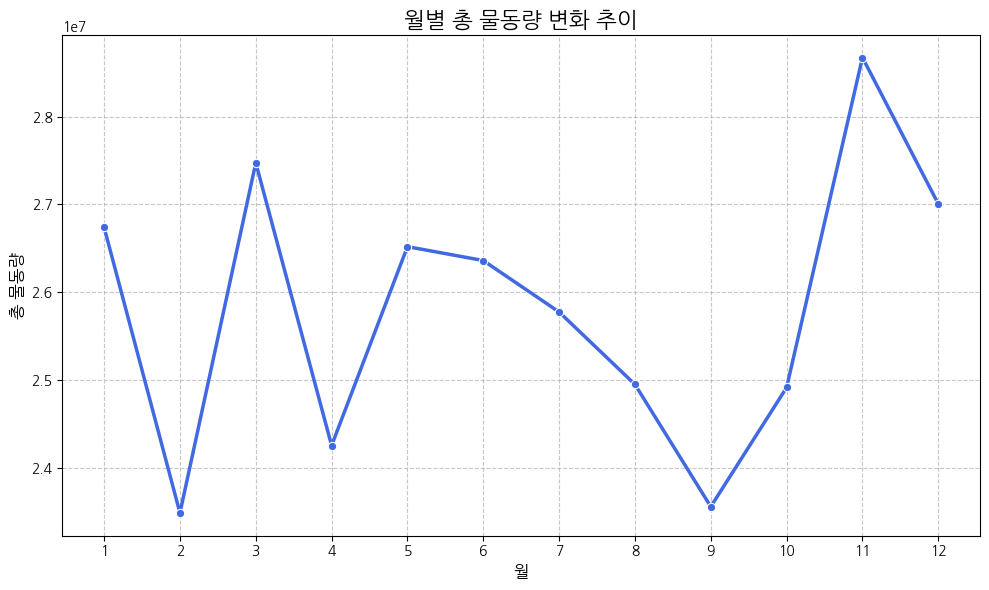

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# ---------- [한글 폰트 및 마이너스 부호 설정] ----------
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
# -------------------------------------------------------
# 2. 합칠 물동량 컬럼 리스트 정의
columns_to_sum = [
    '대분류_착지물동량 가구/인테리어', '대분류_착지물동량 기타', '대분류_착지물동량 도서/음반',
    '대분류_착지물동량 디지털/가전', '대분류_착지물동량 생활/건강', '대분류_착지물동량 스포츠/레저',
    '대분류_착지물동량 식품', '대분류_착지물동량 출산/육아', '대분류_착지물동량 패션의류',
    '대분류_착지물동량 패션잡화', '대분류_착지물동량 화장품/미용'
]

# 3. '총물동량' 파생 변수 생성
final_df['총물동량'] = final_df[columns_to_sum].sum(axis=1)

# 4. 월별 '총물동량' 합계 계산
monthly_total = final_df.groupby('월')['총물동량'].sum().reset_index()

# 5. 월별 총물동량 시각화 (선 그래프)
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_total, x='월', y='총물동량', marker='o', color='royalblue', linewidth=2.5)

# 축 및 타이틀 설정 (한글 적용 완료됨)
plt.title('월별 총 물동량 변화 추이', fontsize=16)
plt.xlabel('월', fontsize=12)
plt.ylabel('총 물동량', fontsize=12)

# X축 눈금을 존재하는 월 기준(1월~12월)으로 모두 표시
month_min = int(monthly_total['월'].min())
month_max = int(monthly_total['월'].max())
plt.xticks(range(month_min, month_max + 1))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
pivot = final_df.pivot_table(
    index='자치구',
    columns='월',
    values='총물동량',
    aggfunc='sum'
)

print(pivot.head())

월         1        2        3        4        5        6        7        8   \
자치구                                                                           
강남구  2108389  1796820  2088840  1883898  2033278  2039500  2013544  1963629   
강동구  1124043   986341  1138975  1006710  1110999  1097863  1076611  1047830   
강북구   622408   548230   643463   566590   629571   626773   615381   589322   
강서구  1580044  1405751  1615763  1432817  1568669  1565610  1528337  1480813   
관악구  1231855  1100280  1300004  1139719  1260996  1260095  1215728  1171147   

월         9        10       11       12  
자치구                                      
강남구  1867076  1919007  2194434  2088707  
강동구   980206  1042493  1198624  1129459  
강북구   552616   593921   674468   637709  
강서구  1366444  1463959  1688419  1593564  
관악구  1079682  1165741  1338475  1250823  


In [ ]:
pivot['감소율'] = (pivot[4] - pivot[3]) / pivot[3] * 100
pivot = pivot.sort_values('감소율')

print(pivot[['감소율']].head(10))

월           감소율
자치구            
금천구  -16.200832
서대문구 -13.370464
동대문구 -12.782048
성북구  -12.686157
마포구  -12.482703
노원구  -12.395298
관악구  -12.329577
광진구  -12.325084
도봉구  -12.232542
은평구  -12.076202


In [ ]:
result = pivot[[3, 4, '감소율']].reset_index()
result.columns = ['자치구', '3월 물동량', '4월 물동량', '감소율(%)']

print(result.head(10))

    자치구   3월 물동량   4월 물동량     감소율(%)
0   금천구   783182   656300 -16.200832
1  서대문구   902579   781900 -13.370464
2  동대문구   989638   863142 -12.782048
3   성북구  1197778  1045826 -12.686157
4   마포구  1281317  1121374 -12.482703
5   노원구  1162352  1018275 -12.395298
6   관악구  1300004  1139719 -12.329577
7   광진구   975539   855303 -12.325084
8   도봉구   676834   594040 -12.232542
9   은평구  1076456   946461 -12.076202


### 물동량 시각화

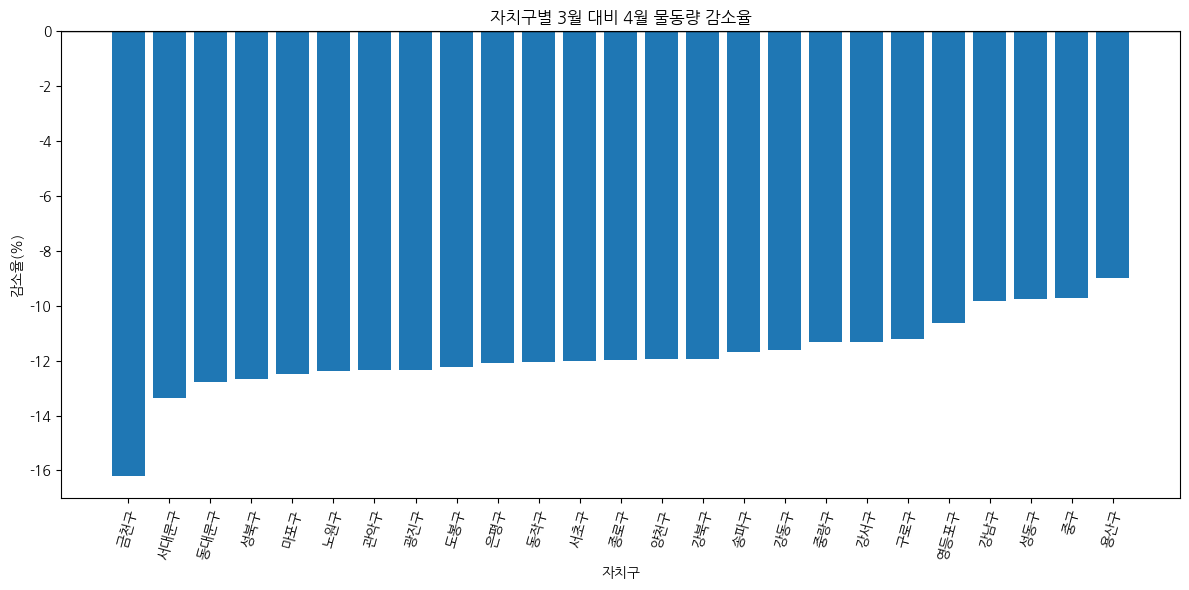

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(result['자치구'], result['감소율(%)'])
plt.axhline(0, color='black', linewidth=1)

plt.title('자치구별 3월 대비 4월 물동량 감소율')
plt.xlabel('자치구')
plt.ylabel('감소율(%)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 검색량 데이터

In [ ]:
data_path = "/content/drive/MyDrive/코드잇_데이터분석_14기/00_ETC/프로젝트01/clean/search.csv"
df_trends = pd.read_csv(data_path)

In [ ]:
# 'Time' 컬럼을 날짜 형식으로 변환
df_trends['Time'] = pd.to_datetime(df_trends['Time'])

# 분석 기간 설정
start_date = '2023-03-01'
end_date = '2023-04-30'
df_2023_spring = df_trends[(df_trends['Time'] >= start_date) & (df_trends['Time'] <= end_date)].copy()

### 검색량 시각화

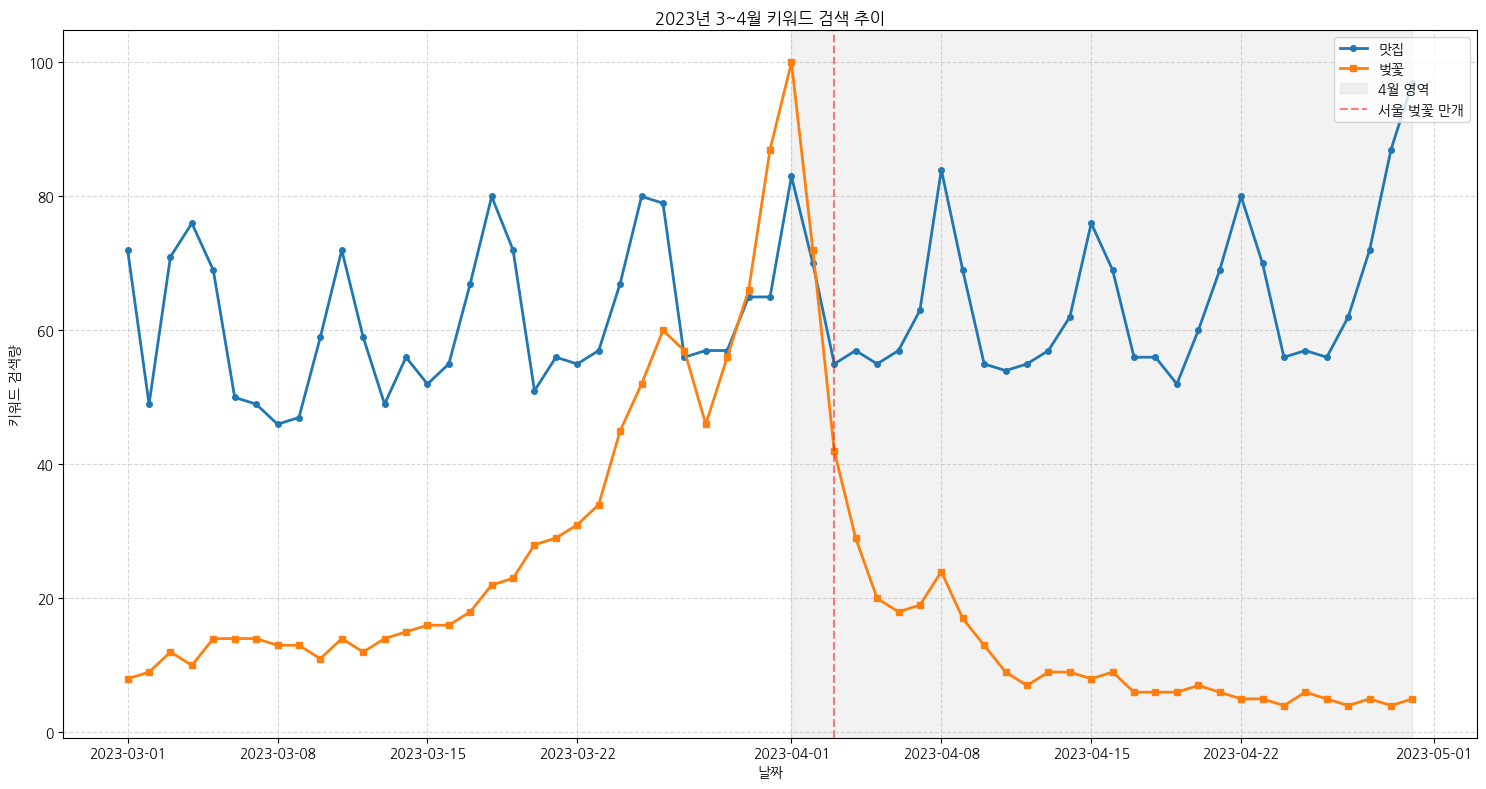

In [ ]:
# 그래프 시각화
plt.figure(figsize=(15, 8))

# '맛집'
plt.plot(df_2023_spring['Time'], df_2023_spring['맛집'],
         label='맛집', marker='o', markersize=4, linewidth=2)

# '벚꽃'
plt.plot(df_2023_spring['Time'], df_2023_spring['벚꽃'],
         label='벚꽃', marker='s', markersize=4, linewidth=2)

# 4월 구간 강조
plt.axvspan(pd.to_datetime('2023-04-01'),
            pd.to_datetime('2023-04-30'),
            alpha=0.1, label='4월 영역', color='gray')

# 벚꽃 만개 시점 표시
plt.axvline(x=pd.to_datetime('2023-04-03'),
            linestyle='--', alpha=0.5, label='서울 벚꽃 만개', color='red')

# 그래프 스타일 설정
plt.title("2023년 3~4월 키워드 검색 추이")
plt.xlabel('날짜')
plt.ylabel('키워드 검색량')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## 기온

In [ ]:
temp_df = final_df[['월', '평균기온(℃)', '평균최저기온(℃)', '평균최고기온(℃)']]

temp_df.head()

,월,평균기온(℃),평균최저기온(℃),평균최고기온(℃)
0,1,-1.522581,-5.693548,3.196774
1,2,2.300000,-1.864286,7.289286
2,3,9.780645,4.180645,16.187097
3,4,13.800000,8.806667,18.953333
4,5,19.522581,14.606452,25.041935


In [ ]:
temp_group = temp_df.groupby(['월'])[[ '평균기온(℃)', '평균최저기온(℃)', '평균최고기온(℃)']].mean().reset_index()
temp_group

,월,평균기온(℃),평균최저기온(℃),평균최고기온(℃)
0,1,-1.522581,-5.693548,3.196774
1,2,2.300000,-1.864286,7.289286
2,3,9.780645,4.180645,16.187097
3,4,13.800000,8.806667,18.953333
4,5,19.522581,14.606452,25.041935
5,6,23.383333,19.746667,27.853333
6,7,26.706452,23.851613,30.193548
7,8,27.187097,24.309677,30.764516
8,9,23.663333,20.233333,27.616667
9,10,15.793548,11.480645,20.993548


###기온 시각화

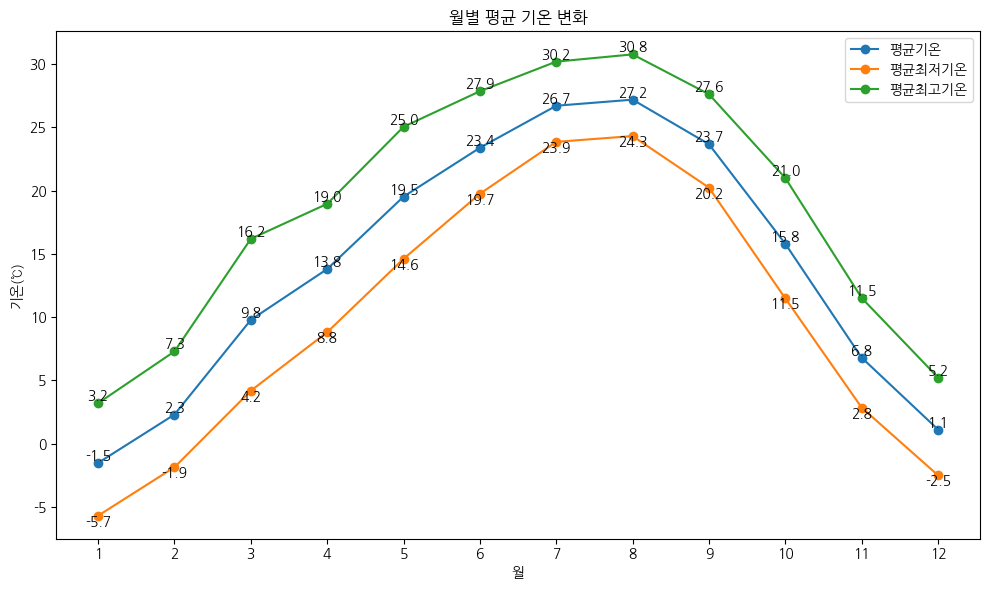

In [ ]:
import koreanize_matplotlib
plt.figure(figsize=(10,6))

plt.plot(temp_group['월'], temp_group['평균기온(℃)'], marker='o', label='평균기온')
plt.plot(temp_group['월'], temp_group['평균최저기온(℃)'], marker='o', label='평균최저기온')
plt.plot(temp_group['월'], temp_group['평균최고기온(℃)'], marker='o', label='평균최고기온')

for i in range(len(temp_group)):
    plt.text(temp_group['월'][i], temp_group['평균기온(℃)'][i],
             round(temp_group['평균기온(℃)'][i],1), ha='center', va='bottom')

    plt.text(temp_group['월'][i], temp_group['평균최저기온(℃)'][i],
             round(temp_group['평균최저기온(℃)'][i],1), ha='center', va='top')

    plt.text(temp_group['월'][i], temp_group['평균최고기온(℃)'][i],
             round(temp_group['평균최고기온(℃)'][i],1), ha='center', va='bottom')


plt.title('월별 평균 기온 변화')
plt.xlabel('월')
plt.ylabel('기온(℃)')
plt.xticks(range(1,13))
plt.legend()

plt.tight_layout()
plt.show()

## 미세먼지


In [ ]:
dust_df = final_df[['월', '미세먼지(㎍/㎥)',	'초미세먼지(㎍/㎥)']]

dust_df.head()

,월,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,1,46.548387,25.032258
1,2,45.928571,27.857143
2,3,65.419355,26.612903
3,4,59.966667,19.300000
4,5,37.806452,17.580645


In [ ]:
dust_group = dust_df.groupby(['월'])[['미세먼지(㎍/㎥)',	'초미세먼지(㎍/㎥)']].mean().reset_index()

dust_group.head()

,월,미세먼지(㎍/㎥),초미세먼지(㎍/㎥)
0,1,48.761434,26.422538
1,2,46.261099,30.372857
2,3,67.752258,30.505806
3,4,62.640000,21.348736
4,5,38.233219,17.820868


### 미세먼지 시각화

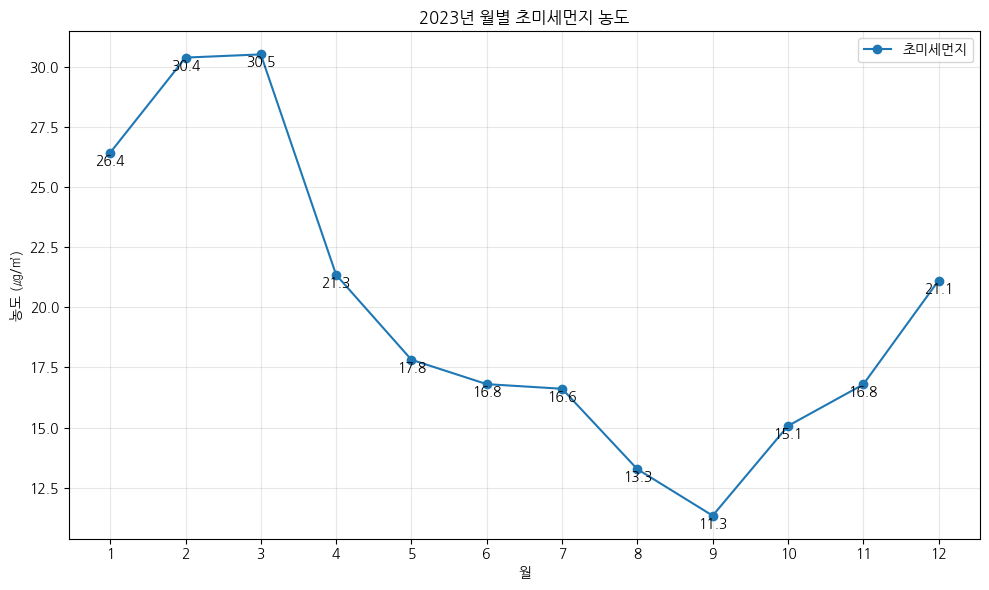

In [ ]:
plt.figure(figsize=(10,6))


plt.plot(dust_group['월'], dust_group['초미세먼지(㎍/㎥)'],
         marker='o', label='초미세먼지')

# 수치 표시
for i in range(len(dust_group)):



    # 초미세먼지
    plt.text(
        dust_group['월'][i],
        dust_group['초미세먼지(㎍/㎥)'][i] - 0.5,
        round(dust_group['초미세먼지(㎍/㎥)'][i],1),
        ha='center'
    )

plt.title('2023년 월별 초미세먼지 농도')
plt.xlabel('월')
plt.ylabel('농도 (㎍/㎥)')
plt.xticks(range(1,13))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 점포

In [ ]:
total_stores = final_df[['월', '자치구', '점포_수']]

total_stores.head()

,월,자치구,점포_수
0,1,강남구,59392.0
1,2,강남구,59392.0
2,3,강남구,59392.0
3,4,강남구,59965.0
4,5,강남구,59965.0


In [ ]:
stores_group = total_stores.groupby(['자치구'])['점포_수'].mean().reset_index().sort_values(by='점포_수', ascending=False)

stores_group['점포_수'] = (stores_group['점포_수'] * 4).astype(int)
stores_group.head()

,자치구,점포_수
0,강남구,240489
17,송파구,164571
14,서초구,157609
23,중구,155631
12,마포구,120929


### 점포시각화

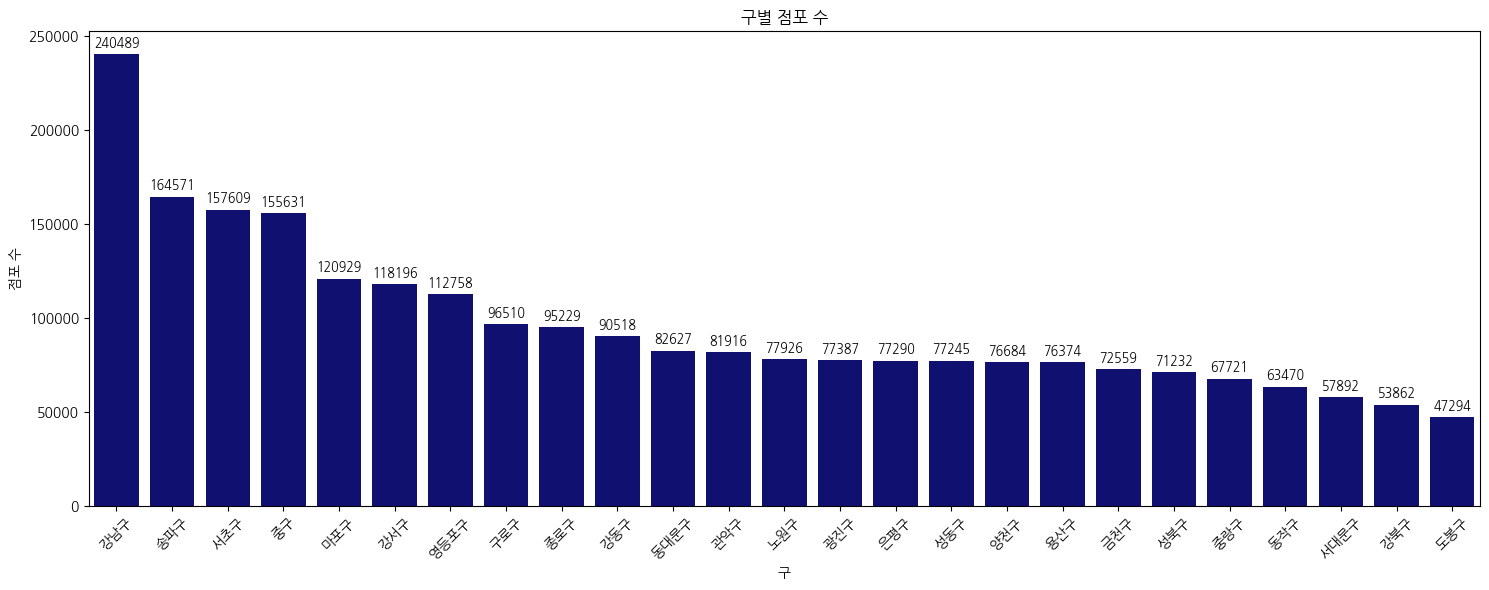

In [ ]:
plt.figure(figsize=(15,6))
ax = sns.barplot(data=stores_group, x='자치구', y='점포_수', color='navy')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9, rotation=0)

plt.title('구별 점포 수')
plt.xlabel('구')
plt.ylabel('점포 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 금천구, 강남구 점포 비교

In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/코드잇_데이터분석_14기/00_ETC/프로젝트01/clean/서울시_구별_상권_데이터.csv")
df2.head()

,기준_년분기_코드,자치구_코드_명,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,개업대비폐업비율,프랜차이즈점포비율,일반점포비율
0,20231,강남구,DVD방,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000
1,20231,강남구,PC방,80.0,90.0,4.4,4.0,4.4,4.0,10.0,1.000000,0.111111,0.888889
2,20231,강남구,가구,525.0,526.0,2.3,12.0,2.3,12.0,1.0,1.000000,0.001901,0.998099
3,20231,강남구,가방,325.0,326.0,1.8,6.0,1.8,6.0,1.0,1.000000,0.003067,0.996933
4,20231,강남구,가전제품,162.0,162.0,1.9,3.0,1.2,2.0,0.0,0.631579,0.000000,1.000000


In [ ]:
service_group = \
df2.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['점포_수'].sum().reset_index()

service_group.head()

,자치구_코드_명,서비스_업종_코드_명,점포_수
0,강남구,DVD방,6.0
1,강남구,PC방,302.0
2,강남구,가구,2111.0
3,강남구,가방,1326.0
4,강남구,가전제품,646.0


In [ ]:
service_group.isnull().sum()

,0
자치구_코드_명,0
서비스_업종_코드_명,0
점포_수,0


###금천구, 강남구 시각화

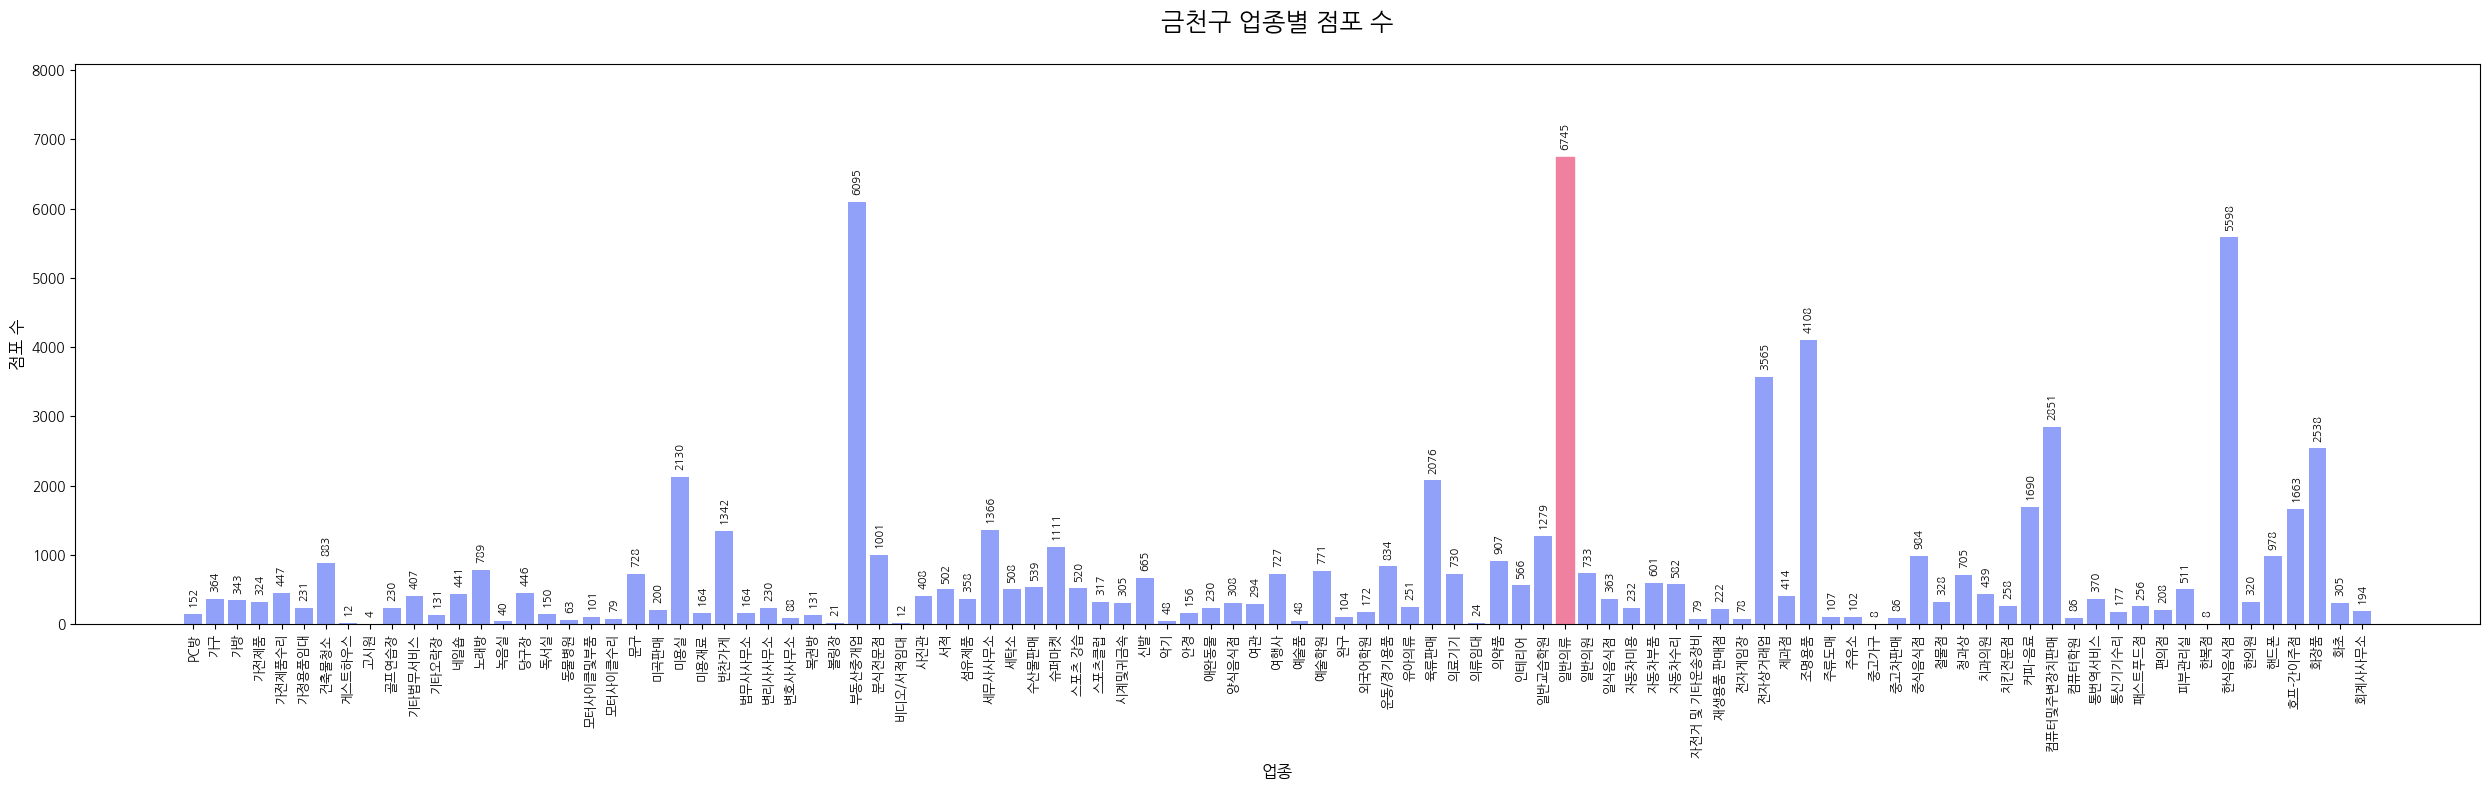

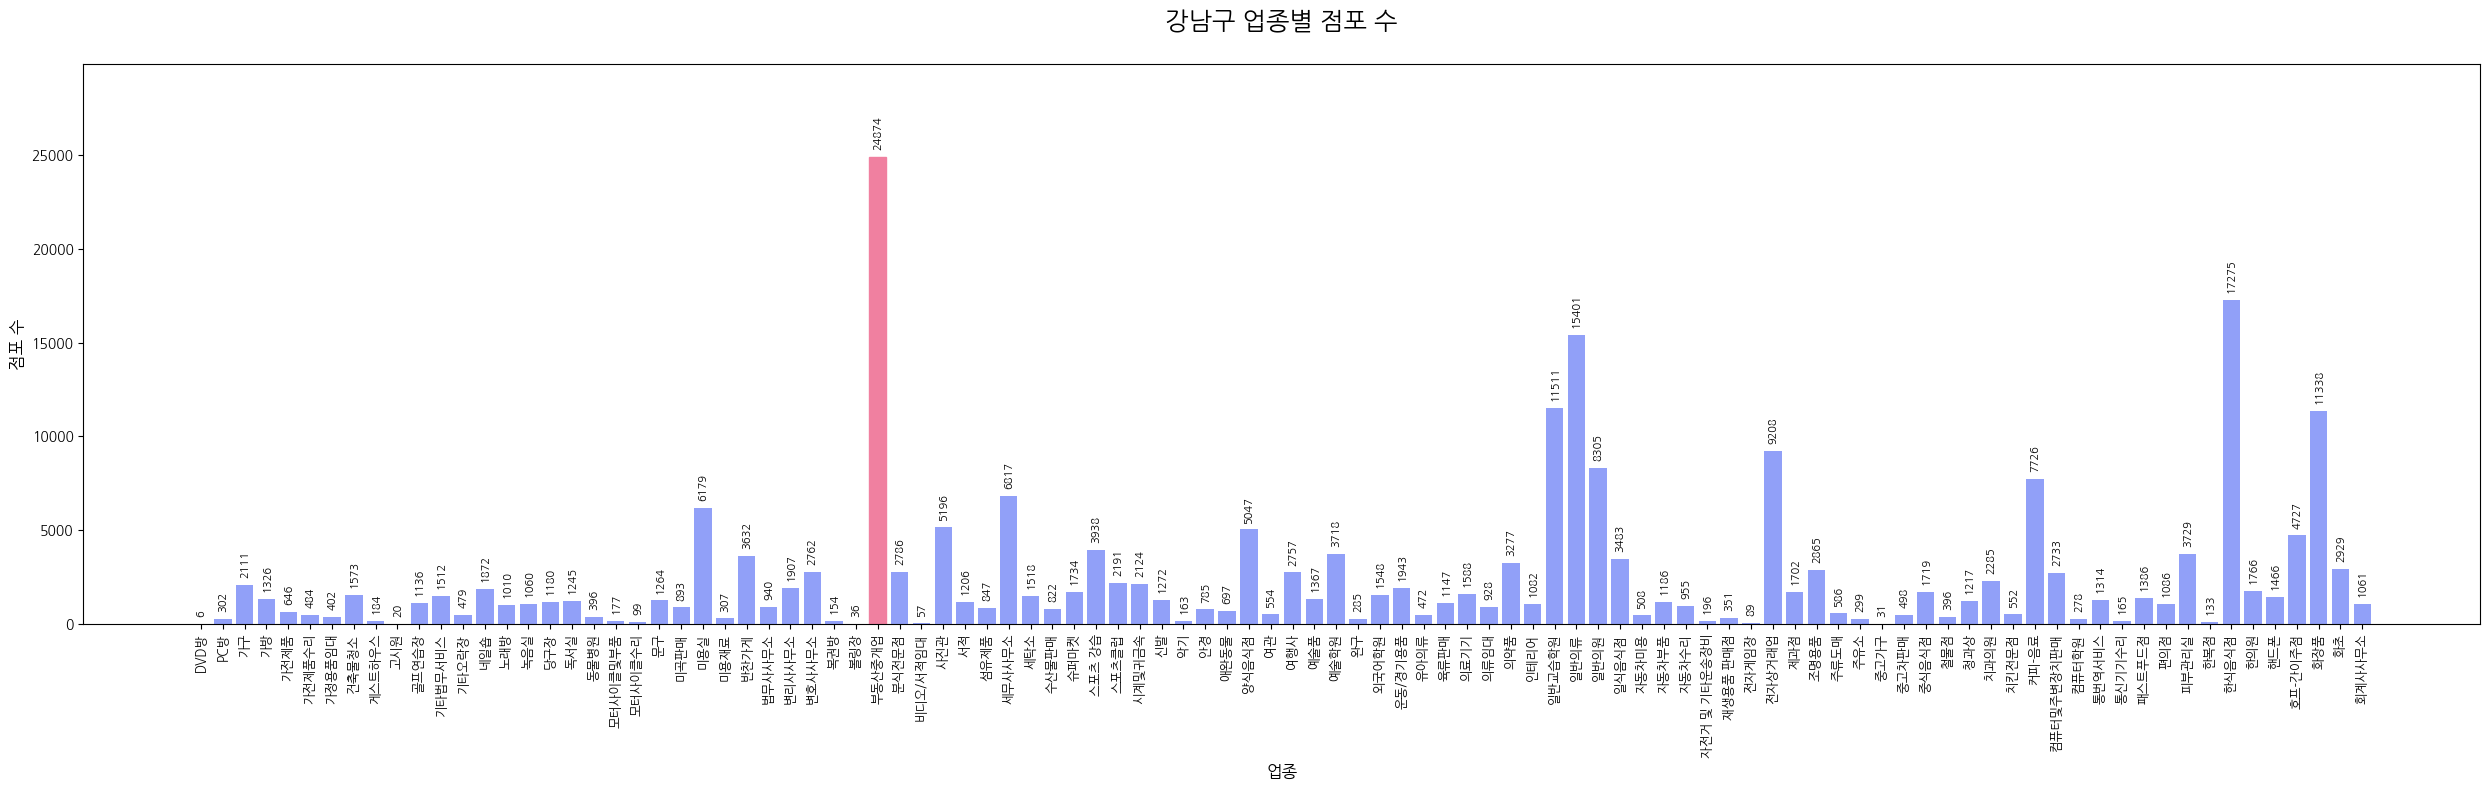

In [ ]:
color_main = '#91a0f8'
color_point = '#f080a0'

gu_list = ['금천구', '강남구']

for gu in gu_list:

    gu_df = service_group.loc[service_group['자치구_코드_명'] == gu].copy()

    gu_df = gu_df.groupby('서비스_업종_코드_명')['점포_수'].sum().reset_index()
    gu_df = gu_df.set_index('서비스_업종_코드_명')

    fig, ax = plt.subplots(figsize=(25, 8))

    bars = ax.bar(gu_df.index, gu_df['점포_수'], color=color_main)

    max_val = gu_df['점포_수'].max()
    for bar in bars:
        if bar.get_height() == max_val:
            bar.set_color(color_point)

    for container in ax.containers:
        ax.bar_label(container,
                     fmt="%.0f",
                     padding=5,
                     fontsize=8,
                     rotation=90)

    ax.set_ylim(0, max_val * 1.2)

    ax.set_title(f'{gu} 업종별 점포 수', fontsize=18, pad=25)
    ax.set_xlabel('업종', fontsize=12)
    ax.set_ylabel('점포 수', fontsize=12)

    plt.xticks(rotation=90, fontsize=9)
    plt.tight_layout()
    plt.show()

## 활동지수

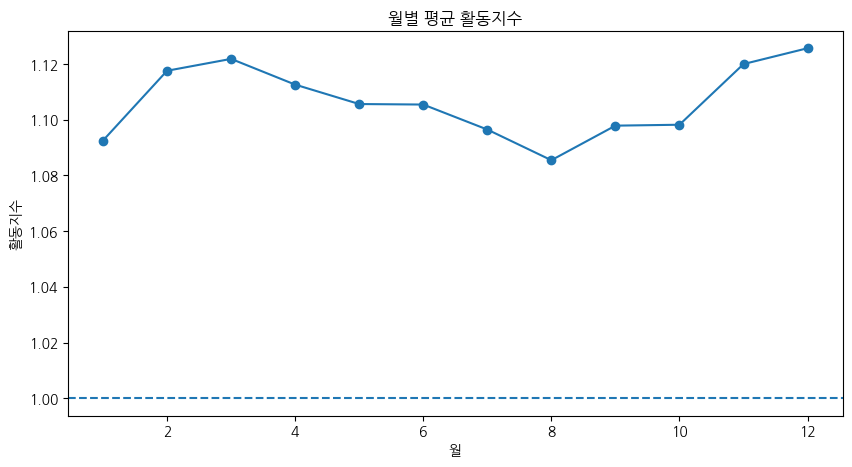

In [ ]:
month_activity = (
    final_df.groupby("월")["활동지수"]
    .mean()
)

plt.figure(figsize=(10,5))

month_activity.plot(marker="o")

plt.axhline(1, linestyle="--")   # 활동지수 기준선
plt.title("월별 평균 활동지수")
plt.xlabel("월")
plt.ylabel("활동지수")

plt.show()

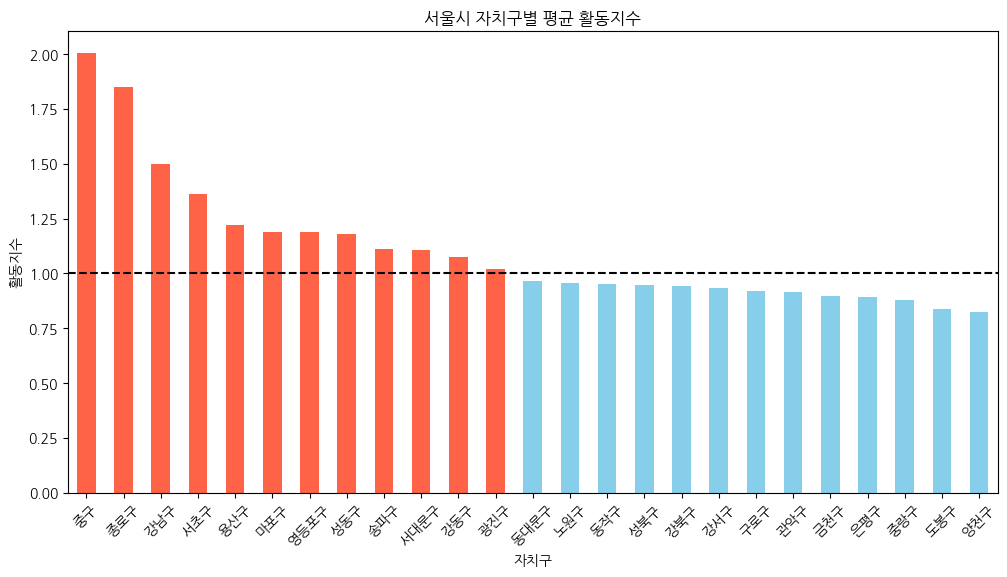

In [ ]:
gu_activity = (
    final_df.groupby("자치구")["활동지수"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

# 활동지수 기준 색 설정
colors = ["tomato" if v > 1 else "skyblue" for v in gu_activity]

gu_activity.plot(
    kind="bar",
    color=colors
)

plt.axhline(1, linestyle="--", color="black")  # 기준선
plt.title("서울시 자치구별 평균 활동지수")
plt.ylabel("활동지수")
plt.xlabel("자치구")
plt.xticks(rotation=45)

plt.show()

## 한강이용객

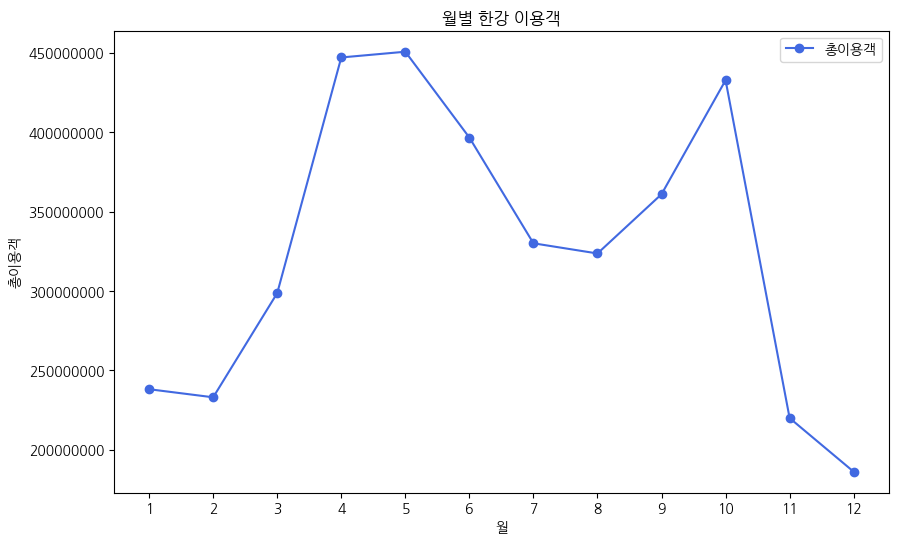

In [ ]:
monthly_visitors = final_df.groupby('월')['총이용객'].sum().reset_index()

# 3. 그래프 그리기
plt.figure(figsize=(10,6))

plt.plot(monthly_visitors["월"], monthly_visitors["총이용객"], marker="o", label="총이용객", color='royalblue')

plt.title("월별 한강 이용객")
plt.xlabel("월")
plt.ylabel("총이용객")
plt.legend()
plt.xticks(range(1,13))

# (선택) Y축 숫자가 지수형태(1e8 등)로 나오는 것을 방지
plt.ticklabel_format(style='plain', axis='y')

plt.show()